In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Predicted next day temperatures sequence: [np.float32(16.821833), np.float32(16.80074), np.float32(16.79305), np.float32(16.756113), np.float32(16.755821)]


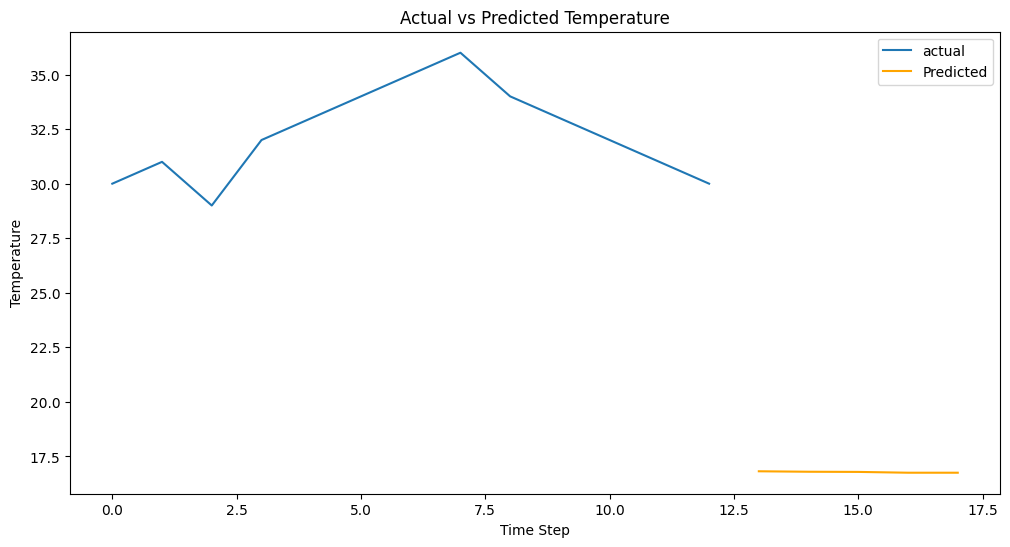

In [8]:
#step1- time series data(temperature)
import numpy as np
import matplotlib.pyplot as plt

data = np.array([30,31,29,32,33,34,35,36,34,33,32,31,30])
#step2 - prepare sequences
def create_dataset(data, time_series=3):
  X,y = [],[]
  for i in range(len(data)-time_series):
    X.append(data[i:i+time_series])
    y.append(data[i+time_series])
  return np.array(X), np.array(y)

X, y = create_dataset(data)

#step 3 - reshape for RNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

#step 3 - build RNN model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(3,1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

#step 4 - train model
model.fit(X,y,epochs = 200, verbose=0)

#step 5 - predict next values (multi-step forecasting)
time_series_window = 3 # This is consistent with the `time_series` parameter in create_dataset

# Use the last `time_series_window` values from the original data as the initial input for prediction
current_input_sequence = list(data[-time_series_window:]) # e.g., [32, 31, 30] for original data

num_prediction_steps = 5 # Number of future steps to predict
future_predictions = []

for _ in range(num_prediction_steps):
    # Reshape the current input sequence for the model
    model_input = np.array(current_input_sequence[-time_series_window:]).reshape((1, time_series_window, 1))

    # Make a prediction
    next_temp = model.predict(model_input, verbose=0)[0][0]

    # Store the prediction
    future_predictions.append(next_temp)

    # Update the input sequence by adding the new prediction
    # The oldest value will be effectively 'dropped' when we select the last `time_series_window` for the next input
    current_input_sequence.append(next_temp)

print("Predicted next day temperatures sequence:", future_predictions)

#graph plot for this sequence (actual vs predicted)
plt.figure(figsize=(12,6))
plt.plot(data, label='actual')

# Plot the predicted values starting from the end of the actual data
predicted_x_coords = np.arange(len(data), len(data) + num_prediction_steps)
plt.plot(predicted_x_coords, future_predictions, label = 'Predicted', color='orange')

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()
plt.show()